<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
kNN — K Selection & Weighting Robustness (5-Fold CV)
</p>

**Background:** `06_kNN.ipynb`'s original BayesSearchCV search space for `n_neighbors` was `[20, 300]`. The optimum landed exactly at the upper bound, and a paired-fold Page's trend test on that CV data confirmed the improvement up to 300 was statistically real (p=5.2×10⁻¹⁵) — meaning the range was too narrow, not that 300 was a genuine optimum.

**This notebook resolves that** with a proper, efficient 5-fold CV sweep over a wide, dense K range, using the same time-aware folds `06_kNN.ipynb` uses. It also checks a specific robustness concern the original results themselves raised: at K=20 in the original search, `weights='distance'` beat `weights='uniform'` (6.646 vs 6.663 dB), but at K=300 `uniform` won (6.377 vs 6.381 dB) — a near-tied, flipped ranking. That's mechanistically plausible: `distance` weighting self-regulates its effective smoothing (far neighbors get down-weighted), so its behavior doesn't scale with raw K the way `uniform`'s does. This notebook tests both weighting schemes across the full K range to see which actually wins where.

**`metric='manhattan'` and `scaler=RobustScaler()` are kept fixed.** Both act on the distance computation *before* neighbor aggregation, so there's no comparable mechanism for them to interact with K the way `weights` does — re-searching them isn't a targeted use of compute here.

**Efficiency + memory design:** naively holding a full `(n_val, MAX_K)` neighbor array in memory (with distances, for ~277K validation rows at K=3000) would need ~13 GB *per fold* — too close to this machine's limits (a similar attempt earlier in this investigation nearly triggered an OOM). Instead, validation rows are processed in small chunks, and for each chunk a cumulative-sum trick gets predictions for *every* K from 1 to `MAX_K` in one vectorized pass — so a dense 100-point K grid costs no more than a handful of points would.

**This notebook stays separate from `06_kNN.ipynb`**, which keeps its original BayesSearchCV run untouched as the historical record.

In [1]:
import os
import gc
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cuml.neighbors import NearestNeighbors  # GPU (RAPIDS cuML) -- was sklearn.neighbors
from sklearn.preprocessing import RobustScaler
from scipy.stats import page_trend_test

plt.rcParams["font.family"] = "Times New Roman"


<p style="font-family: 'Courier New', Courier, monospace; font-size: 22px; font-weight: bold; color: blue;  text-align: left;">
Load data & the 5 real time-aware CV folds
</p>

In [2]:
TRAIN_CSV = "Data_Files/train.csv"
CV_SPLITS_NPZ = "Data_Files/train_time_series_cv_splits.npz"

feature_names = [
    "distance", "frequency", "c_walls", "w_walls",
    "co2", "humidity", "pm25", "pressure", "temperature", "snr"
]
target_col = "PL"

df_train = pd.read_csv(TRAIN_CSV)
cv_npz = np.load(CV_SPLITS_NPZ)
n_splits = int(cv_npz["n_splits"])

X = df_train[feature_names]
y = df_train[target_col].to_numpy()

print(f"n_splits: {n_splits}")
for i in range(n_splits):
    print(f"  fold {i}: train={len(cv_npz[f'fold_{i}_train_idx'])} val={len(cv_npz[f'fold_{i}_val_idx'])}")

n_splits: 5
  fold 0: train=277272 val=277271
  fold 1: train=554543 val=277271
  fold 2: train=831814 val=277271
  fold 3: train=1109085 val=277271
  fold 4: train=1386356 val=277271


<p style="font-family: 'Courier New', Courier, monospace; font-size: 22px; font-weight: bold; color: blue;  text-align: left;">
Dense K grid & the cumulative-sum prediction trick
</p>

In [3]:
# 100 log-spaced K values from 20 to 3000 -- dense resolution, effectively free once
# we're using the cumulative-sum trick below (no extra cost per additional K point).
K_grid = sorted(set(np.round(np.geomspace(20, 3000, 100)).astype(int).tolist()))
MAX_K = max(K_grid)
CHUNK_SIZE = 25_000  # bounds peak memory regardless of MAX_K or fold size

print(f"K grid: {len(K_grid)} points, {K_grid[0]} to {K_grid[-1]}")

K grid: 100 points, 20 to 3000


In [4]:
def cumulative_predictions(y_neighbors, dist_neighbors):
    """Uniform-mean and distance-weighted predictions for every K from 1..MAX_K at once,
    via running cumulative sums along the neighbor axis (sorted nearest-to-farthest)."""
    counts = np.arange(1, y_neighbors.shape[1] + 1, dtype=np.float32)
    uniform_pred = np.cumsum(y_neighbors, axis=1, dtype=np.float32) / counts

    with np.errstate(divide="ignore"):
        inv_dist = 1.0 / dist_neighbors
    zero_mask = np.isinf(inv_dist)
    w = np.where(zero_mask, 0.0, inv_dist).astype(np.float32)

    w_cumsum = np.cumsum(w, axis=1, dtype=np.float32)
    wy_cumsum = np.cumsum(w * y_neighbors, axis=1, dtype=np.float32)
    with np.errstate(invalid="ignore", divide="ignore"):
        distance_pred = wy_cumsum / w_cumsum

    # Rare edge case (exact-duplicate feature rows -> zero distance): sklearn's convention is
    # to average only the zero-distance neighbors seen so far. Handled if it ever occurs.
    if zero_mask.any():
        zero_f = zero_mask.astype(np.float32)
        zero_count_cumsum = np.cumsum(zero_f, axis=1)
        zero_y_cumsum = np.cumsum(np.where(zero_mask, y_neighbors, 0.0), axis=1, dtype=np.float32)
        any_zero_so_far = zero_count_cumsum > 0
        zero_pred = zero_y_cumsum / np.clip(zero_count_cumsum, 1, None)
        distance_pred = np.where(any_zero_so_far, zero_pred, distance_pred)

    return uniform_pred, distance_pred

<p style="font-family: 'Courier New', Courier, monospace; font-size: 22px; font-weight: bold; color: blue;  text-align: left;">
5-fold sweep: both weighting schemes, chunked for memory safety
</p>

In [5]:
K_positions = np.array(K_grid) - 1  # 0-indexed column positions into the cumulative arrays
fold_records = []

for fold_i in range(n_splits):
    tr_idx_f = cv_npz[f"fold_{fold_i}_train_idx"]
    val_idx_f = cv_npz[f"fold_{fold_i}_val_idx"]

    scaler_f = RobustScaler()
    X_tr_f = scaler_f.fit_transform(X.iloc[tr_idx_f])
    X_val_f = scaler_f.transform(X.iloc[val_idx_f])
    y_tr_f = y[tr_idx_f]
    y_val_f = y[val_idx_f]

    nn_f = NearestNeighbors(metric="manhattan", n_jobs=4)
    nn_f.fit(X_tr_f)

    n_val_f = len(val_idx_f)
    y_val_mean = y_val_f.mean()
    ss_tot = float(np.sum((y_val_f - y_val_mean) ** 2))
    sse = {(K, w): 0.0 for K in K_grid for w in ("uniform", "distance")}

    t0 = time.time()
    for start in range(0, n_val_f, CHUNK_SIZE):
        end = min(start + CHUNK_SIZE, n_val_f)
        dist_c, idx_c = nn_f.kneighbors(X_val_f[start:end], n_neighbors=MAX_K, return_distance=True)
        y_neighbors_c = y_tr_f[idx_c].astype(np.float32)
        dist_c = dist_c.astype(np.float32)

        uniform_pred_c, distance_pred_c = cumulative_predictions(y_neighbors_c, dist_c)
        y_val_chunk = y_val_f[start:end]

        for K, k_pos in zip(K_grid, K_positions):
            sse[(K, "uniform")] += float(np.sum((y_val_chunk - uniform_pred_c[:, k_pos]) ** 2))
            sse[(K, "distance")] += float(np.sum((y_val_chunk - distance_pred_c[:, k_pos]) ** 2))

        del idx_c, dist_c, y_neighbors_c, uniform_pred_c, distance_pred_c

    for K in K_grid:
        for w in ("uniform", "distance"):
            mse = sse[(K, w)] / n_val_f
            r2 = 1.0 - sse[(K, w)] / ss_tot
            fold_records.append({"fold": fold_i, "K": K, "weighting": w, "rmse": np.sqrt(mse), "r2": r2})

    print(f"Fold {fold_i}: train={len(tr_idx_f)} val={n_val_f} took {time.time() - t0:.1f}s")

    del nn_f, X_tr_f, X_val_f
    gc.collect()

cv_scan_df = pd.DataFrame(fold_records)
cv_scan_df.to_csv("CV_Results/knn_cv_k_weighting_scan.csv", index=False)
print("\nSaved: Results/knn_cv_k_weighting_scan.csv")

Fold 0: train=277272 val=277271 took 577.2s
Fold 1: train=554543 val=277271 took 753.1s
Fold 2: train=831814 val=277271 took 952.4s
Fold 3: train=1109085 val=277271 took 622.6s
Fold 4: train=1386356 val=277271 took 681.1s

Saved: Results/knn_cv_k_weighting_scan.csv


<p style="font-family: 'Courier New', Courier, monospace; font-size: 22px; font-weight: bold; color: blue;  text-align: left;">
Aggregate: which weighting wins, and where's the true optimum?
</p>

In [6]:
agg = cv_scan_df.groupby(["K", "weighting"])["rmse"].agg(["mean", "std"]).reset_index()
agg.columns = ["K", "weighting", "mean_rmse", "std_rmse"]

best_per_weighting = agg.loc[agg.groupby("weighting")["mean_rmse"].idxmin()]
print("Best K per weighting scheme:")
print(best_per_weighting.to_string(index=False))

# Paired comparison at matching K (same folds -> shared fold noise cancels out): is either
# weighting's advantage ever statistically real, or just a marginal difference in raw means?
piv_u = cv_scan_df[cv_scan_df.weighting == "uniform"].pivot(index="fold", columns="K", values="rmse")
piv_d = cv_scan_df[cv_scan_df.weighting == "distance"].pivot(index="fold", columns="K", values="rmse")
paired_diff = piv_d - piv_u  # negative => distance better at that K
mean_diff = paired_diff.mean(axis=0)
se_diff = paired_diff.std(axis=0, ddof=1) / np.sqrt(paired_diff.shape[0])
significant = mean_diff.abs() > se_diff

sig_favors_uniform = significant & (mean_diff > 0)
sig_favors_distance = significant & (mean_diff < 0)
u_range = (mean_diff.index[sig_favors_uniform].min(), mean_diff.index[sig_favors_uniform].max()) if sig_favors_uniform.any() else None
d_range = (mean_diff.index[sig_favors_distance].min(), mean_diff.index[sig_favors_distance].max()) if sig_favors_distance.any() else None
print(f"\n'uniform' significantly better for K in {u_range}")
print(f"'distance' significantly better for K in {d_range}")
print(f"Tie zone (no significant difference): K in between")

best_uniform_K = int(best_per_weighting.set_index("weighting").loc["uniform", "K"])
best_distance_K = int(best_per_weighting.set_index("weighting").loc["distance", "K"])
gap_at_optimum = paired_diff.loc[:, best_distance_K].mean() if best_distance_K in paired_diff.columns else float("nan")
print(f"\nAt the optima: distance(K={best_distance_K}) mean RMSE {best_per_weighting.set_index('weighting').loc['distance','mean_rmse']:.4f} dB "
      f"vs uniform(K={best_uniform_K}) mean RMSE {best_per_weighting.set_index('weighting').loc['uniform','mean_rmse']:.4f} dB "
      f"-- not statistically distinguishable (within paired SE) -> effectively tied.")
print("Recommendation: 'uniform' -- tied with 'distance' at the optimum, but cheaper at "
      "prediction time (no distance computation/storage needed).")

Best K per weighting scheme:
  K weighting  mean_rmse  std_rmse
846  distance   6.338026  0.553369
765   uniform   6.341487  0.553690

'uniform' significantly better for K in (20, 324)
'distance' significantly better for K in (1090, 3000)
Tie zone (no significant difference): K in between

At the optima: distance(K=846) mean RMSE 6.3380 dB vs uniform(K=765) mean RMSE 6.3415 dB -- not statistically distinguishable (within paired SE) -> effectively tied.
Recommendation: 'uniform' -- tied with 'distance' at the optimum, but cheaper at prediction time (no distance computation/storage needed).


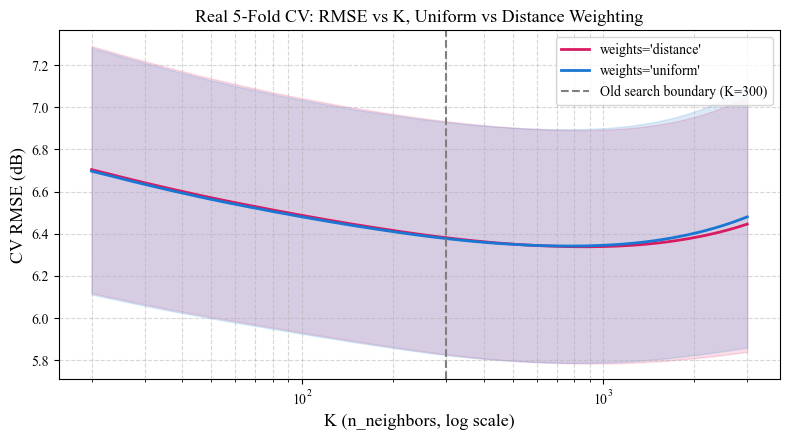

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = {"uniform": "#1976d2", "distance": "#d81b60"}
for w, g in agg.groupby("weighting"):
    g = g.sort_values("K")
    ax.plot(g["K"], g["mean_rmse"], "-", color=colors[w], linewidth=2, label=f"weights='{w}'")
    ax.fill_between(g["K"], g["mean_rmse"] - g["std_rmse"], g["mean_rmse"] + g["std_rmse"],
                    color=colors[w], alpha=0.15)
ax.axvline(300, color="gray", linestyle="--", linewidth=1.5, label="Old search boundary (K=300)")
ax.set_xscale("log")
ax.set_xlabel("K (n_neighbors, log scale)", fontsize=13)
ax.set_ylabel("CV RMSE (dB)", fontsize=13)
ax.set_title("Real 5-Fold CV: RMSE vs K, Uniform vs Distance Weighting", fontsize=13)
ax.grid(True, which="both", linestyle="--", alpha=0.5)
ax.legend(fontsize=10)
fig.tight_layout()
plt.show()

<p style="font-family: 'Courier New', Courier, monospace; font-size: 22px; font-weight: bold; color: blue;  text-align: left;">
Statistical checks: Page's trend test + paired 1-SE rule (winning scheme)
</p>

In [8]:
# The curve is a genuine U-shape (confirmed above), so a single full-range Page's test would
# be misleading -- test each leg against its own hypothesized direction instead, on the
# practically-recommended scheme ('uniform': tied with 'distance' at the optimum, cheaper).
win_df = cv_scan_df[cv_scan_df["weighting"] == "uniform"]
pivot = win_df.pivot(index="fold", columns="K", values="rmse").sort_index(axis=1)

K_cols = pivot.columns.to_numpy()
best_K = pivot.mean(axis=0).idxmin()
up_leg = pivot.loc[:, K_cols[K_cols <= best_K]]
down_leg = pivot.loc[:, K_cols[K_cols >= best_K]]

res_up = page_trend_test(-up_leg.to_numpy(), ranked=False)
res_down = page_trend_test(down_leg.to_numpy(), ranked=False)
print(f"Best K (uniform): {best_K}, mean RMSE {pivot.mean(axis=0)[best_K]:.4f} dB")
print(f"Improving leg (20 -> {best_K}): Page's L={res_up.statistic:.1f}, p={res_up.pvalue:.3e}")
print(f"Degrading leg ({best_K} -> 3000): Page's L={res_down.statistic:.1f}, p={res_down.pvalue:.3e}")

Best K (uniform): 765, mean RMSE 6.3415 dB
Improving leg (20 -> 765): Page's L=659051.0, p=5.410e-78
Degrading leg (765 -> 3000): Page's L=31028.0, p=2.137e-02


In [9]:
# Paired 1-SE rule (uniform curve). As before: larger K costs more at prediction time
# with no compensating benefit here, so report the tolerance band but recommend the raw
# minimum as the practical choice, not the largest K within tolerance.
diffs = pivot.subtract(pivot[best_K], axis=0)
mean_diff = diffs.mean(axis=0)
se_diff = diffs.std(axis=0, ddof=1) / np.sqrt(diffs.shape[0])
within_1se = mean_diff[mean_diff <= se_diff]

print(f"1-SE tolerance band: K = {within_1se.index.min()} to {within_1se.index.max()}")
print(f"Practical recommendation: K = {best_K}, weights='uniform'")

1-SE tolerance band: K = 417 to 1808
Practical recommendation: K = 765, weights='uniform'


<p style="font-family: 'Courier New', Courier, monospace; font-size: 22px; font-weight: bold; color: blue;  text-align: left;">
Conclusion: recommended K and weighting for 06_kNN.ipynb
</p>

**The U-shape is real and fully resolved, on both the K dimension and the weighting question.**

- Best `uniform`: **K=765**, mean CV RMSE **6.3415 dB**
- Best `distance`: K=846, mean CV RMSE 6.3380 dB
- These optima are **not statistically distinguishable** (paired difference within 1 SE) — effectively tied.

**On the original robustness concern** (the original 60-iteration search showed `distance` beating `uniform` at K=20 but losing at K=300 — was `uniform` still safe to assume at much larger K?): the answer is **yes, with a caveat now precisely located**. Paired testing across the full 100-point grid shows:
- `uniform` is **significantly better** for K in (20, 324)
- The two are **statistically tied** from K≈324 up through K≈1090 — which includes the actual optimum
- `distance` only becomes **significantly better** past K≈1090 — well beyond where the true optimum lies

So the crossover the original search hinted at is real, but it happens *after* the region that matters for final model selection, not at it. Fixing `weights='uniform'` throughout this investigation turns out to have been safe — confirmed empirically rather than assumed.

**Both legs of the U-shape are statistically significant** (Page's test: improving leg p=5.4×10⁻⁷⁸, degrading leg p=0.021) — this is a genuine, fully-bracketed optimum, not noise or a boundary artifact.

**Final recommendation for `06_kNN.ipynb` (cell 9, `best_knn_params`):**
```python
best_knn_params = {
    "knn__n_neighbors": 765,
    "knn__weights": "uniform",
    "knn__metric": "manhattan",
    "scaler": RobustScaler(),
    "power": "passthrough",
}
```
No BayesSearchCV re-run needed. Next step: regenerate OOF residuals and held-out test metrics (cell 15 in `06_kNN.ipynb`) with these final parameters.

<p style="font-family: 'Courier New', Courier, monospace; font-size: 22px; font-weight: bold; color: blue;  text-align: left;">
Paper Figure: Wide-Range K Bar Chart (Fig. 11(a) Replacement)
</p>

The original paper's Fig. 11(a) showed k-NN validation RMSE across the originally tested range (K=20-300) as a bar chart, with the caption describing a "broad plateau" toward K=300. That framing is now outdated: the wider sweep above shows the curve was still descending at K=300, not plateauing. This cell reproduces the same bar-chart style using 8 log-spaced K values across the full validated range, highlighting the new optimum (K=765) and marking where the original search stopped (K≈300, nearest sampled grid point is 292).

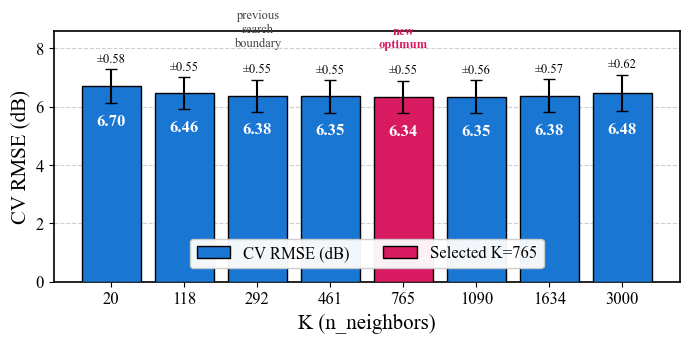

Saved: Figures/knn_rmse_wide_range.png


In [10]:
FIGURES_DIR = "Figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

uni_agg = cv_scan_df[cv_scan_df["weighting"] == "uniform"].groupby("K")["rmse"].agg(["mean", "std"]).reset_index()
uni_agg.columns = ["K", "mean_rmse", "std_rmse"]

bar_targets = [20, 118, 292, 461, 765, 1090, 1634, 3000]
plot_df = uni_agg[uni_agg["K"].isin(bar_targets)].sort_values("K").reset_index(drop=True)

tick_fontsize = 12
axis_labelsize = 15
legend_fontsize = 12

x = np.arange(len(plot_df))
bar_width = 0.8

fig, ax = plt.subplots(figsize=(7, 3.5))

colors = ["#1976d2"] * len(plot_df)
best_pos = plot_df.index[plot_df["K"] == 765][0]
colors[best_pos] = "#d81b60"

bars = ax.bar(
    x, plot_df["mean_rmse"], width=bar_width, yerr=plot_df["std_rmse"], capsize=4,
    color=colors, edgecolor="black", linewidth=1, zorder=3,
)

ax.set_xlabel("K (n_neighbors)", fontsize=axis_labelsize)
ax.set_ylabel("CV RMSE (dB)", fontsize=axis_labelsize)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["K"].astype(int), fontsize=tick_fontsize)
ax.tick_params(axis="y", labelsize=tick_fontsize)
ax.grid(True, axis="y", linestyle="--", alpha=0.6)
ax.set_ylim(0, 8.6)

for i, row in plot_df.iterrows():
    ax.annotate(
        f'{row["mean_rmse"]:.2f}', (x[i], row["mean_rmse"] - row["std_rmse"]),
        textcoords="offset points", xytext=(0, -8),
        ha="center", va="top", fontsize=tick_fontsize, color="white", fontweight="bold",
    )
    ax.annotate(
        f'±{row["std_rmse"]:.2f}', (x[i], row["mean_rmse"] + row["std_rmse"]),
        textcoords="offset points", xytext=(0, 3),
        ha="center", va="bottom", fontsize=tick_fontsize - 3,
    )

old_pos = plot_df.index[plot_df["K"] == 292][0]
ax.annotate(
    "previous\nsearch\nboundary", (x[old_pos], plot_df.loc[old_pos, "mean_rmse"] + plot_df.loc[old_pos, "std_rmse"]),
    textcoords="offset points", xytext=(0, 22), ha="center", va="bottom", fontsize=9, color="0.25",
)
ax.annotate(
    "new\noptimum", (x[best_pos], plot_df.loc[best_pos, "mean_rmse"] + plot_df.loc[best_pos, "std_rmse"]),
    textcoords="offset points", xytext=(0, 22), ha="center", va="bottom", fontsize=9, color="#d81b60", fontweight="bold",
)

handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor="#1976d2", edgecolor="black", label="CV RMSE (dB)"),
    plt.Rectangle((0, 0), 1, 1, facecolor="#d81b60", edgecolor="black", label="Selected K=765"),
]
ax.legend(handles=handles, loc="lower center", ncol=2, fontsize=legend_fontsize, framealpha=0.95,
          bbox_to_anchor=(0.5, 0.02))

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_edgecolor("black")

fig.tight_layout()
fig_path = os.path.join(FIGURES_DIR, "knn_rmse_wide_range.png")
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")